# 04 · Exploratory Data Analysis (EDA)
**Project:** EV Charging Demand & Cost Analytics + Predictive System  
**Input:** `data/processed/ev_charging_features.csv`  

---

### Goals
1. Distribution of Charging Cost and Energy Consumed
2. Time of Day and Day of Week analysis
3. Geographic comparisons (Charging Station Location)
4. Charger Type efficiency and cost
5. User Type behavior patterns
6. Temperature vs. Charging Rate relationship
7. Feature correlations
8. Key Insights Summary
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'figure.titlesize': 16, 'axes.titlesize': 14, 'axes.labelsize': 12})

FEATURES_PATH = '../data/processed/ev_charging_features.csv'
df = pd.read_csv(FEATURES_PATH)

print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded dataset: 1,320 rows × 30 columns


,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),...,soc_was_swapped,is_weekend,soc_gained_pct,charging_efficiency,cost_per_kwh,battery_utilization_ratio,hour_of_day,month,distance_per_kwh,charger_type_ordinal
0,User_1,Bmw I3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,...,0,0,56.748386,102.665033,0.215569,0.559752,0,1,4.835954,3
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,...,0,0,74.548566,3.937666,1.712292,0.123393,1,1,9.085850,1
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,...,0,0,63.063011,7.799260,1.864577,0.255052,2,1,3.753449,2


---
## 1. Distribution of Charging Cost & Energy Consumed

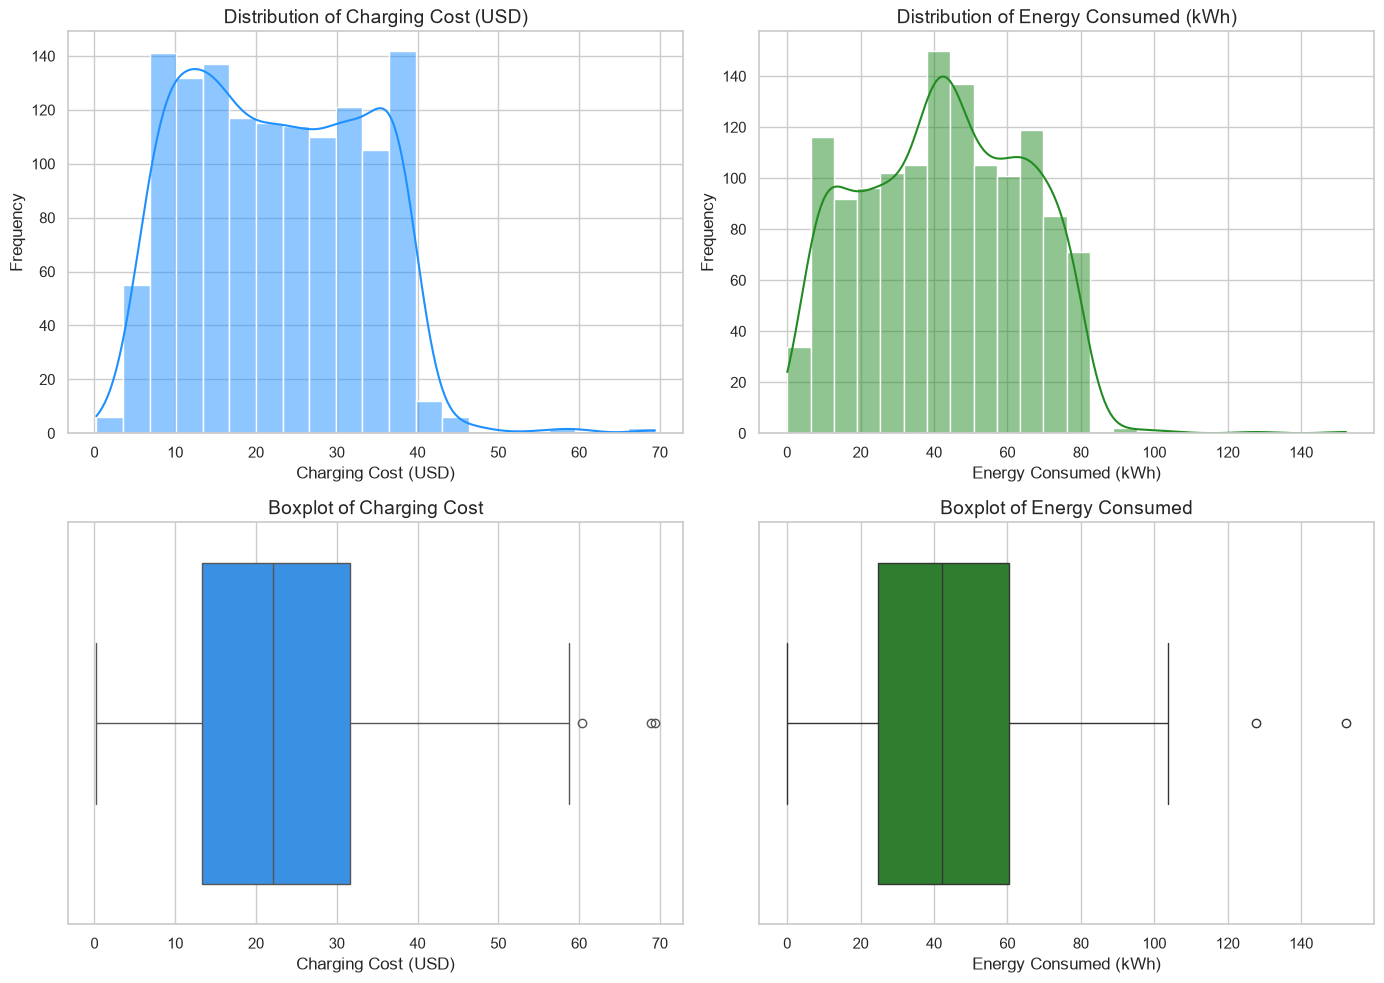

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograms
sns.histplot(df['Charging Cost (USD)'], kde=True, ax=axes[0, 0], color='dodgerblue')
axes[0, 0].set_title('Distribution of Charging Cost (USD)')
axes[0, 0].set_xlabel('Charging Cost (USD)')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df['Energy Consumed (kWh)'], kde=True, ax=axes[0, 1], color='forestgreen')
axes[0, 1].set_title('Distribution of Energy Consumed (kWh)')
axes[0, 1].set_xlabel('Energy Consumed (kWh)')
axes[0, 1].set_ylabel('Frequency')

# Boxplots
sns.boxplot(x=df['Charging Cost (USD)'], ax=axes[1, 0], color='dodgerblue')
axes[1, 0].set_title('Boxplot of Charging Cost')
axes[1, 0].set_xlabel('Charging Cost (USD)')

sns.boxplot(x=df['Energy Consumed (kWh)'], ax=axes[1, 1], color='forestgreen')
axes[1, 1].set_title('Boxplot of Energy Consumed')
axes[1, 1].set_xlabel('Energy Consumed (kWh)')

plt.tight_layout()
plt.show()

---
## 2. Temporal Analysis: Time of Day & Day of Week

C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\2495241897.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Time of Day', y='Charging Cost (USD)', order=tod_order, ax=axes[0, 0], errorbar='sd', palette='muted')
C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\2495241897.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Time of Day', y='Energy Consumed (kWh)', order=tod_order, ax=axes[0, 1], errorbar='sd', palette='muted')
C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\2495241897.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sa

C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\2495241897.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Day of Week', y='Energy Consumed (kWh)', order=dow_order, ax=axes[1, 1], errorbar='sd', palette='pastel')


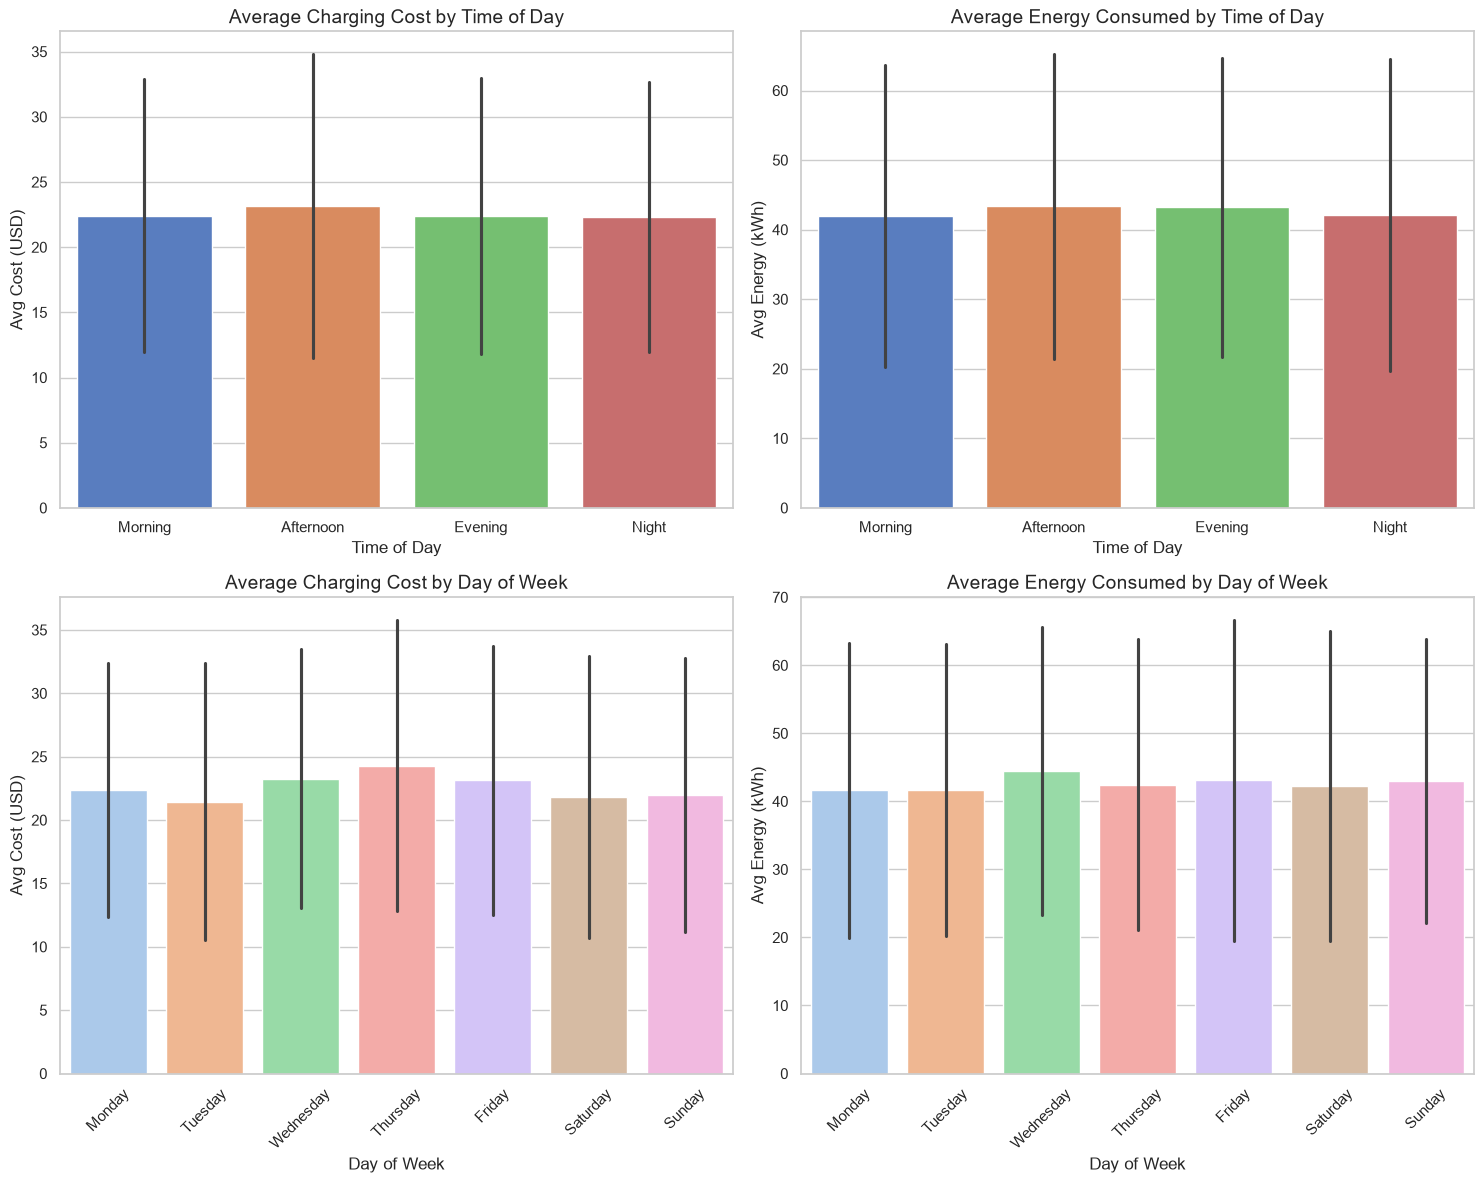

In [3]:
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Cost by Time of Day
sns.barplot(data=df, x='Time of Day', y='Charging Cost (USD)', order=tod_order, ax=axes[0, 0], errorbar='sd', palette='muted')
axes[0, 0].set_title('Average Charging Cost by Time of Day')
axes[0, 0].set_ylabel('Avg Cost (USD)')

# Energy by Time of Day
sns.barplot(data=df, x='Time of Day', y='Energy Consumed (kWh)', order=tod_order, ax=axes[0, 1], errorbar='sd', palette='muted')
axes[0, 1].set_title('Average Energy Consumed by Time of Day')
axes[0, 1].set_ylabel('Avg Energy (kWh)')

# Cost by Day of Week
sns.barplot(data=df, x='Day of Week', y='Charging Cost (USD)', order=dow_order, ax=axes[1, 0], errorbar='sd', palette='pastel')
axes[1, 0].set_title('Average Charging Cost by Day of Week')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylabel('Avg Cost (USD)')

# Energy by Day of Week
sns.barplot(data=df, x='Day of Week', y='Energy Consumed (kWh)', order=dow_order, ax=axes[1, 1], errorbar='sd', palette='pastel')
axes[1, 1].set_title('Average Energy Consumed by Day of Week')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylabel('Avg Energy (kWh)')

plt.tight_layout()
plt.show()

---
## 3. Geographic Comparison: City Locations

C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\3881116977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Charging Station Location', y='Charging Cost (USD)', ax=axes[0], palette='Set2')
C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\3881116977.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Charging Station Location', y='Charging Duration (hours)', ax=axes[1], palette='Set3')


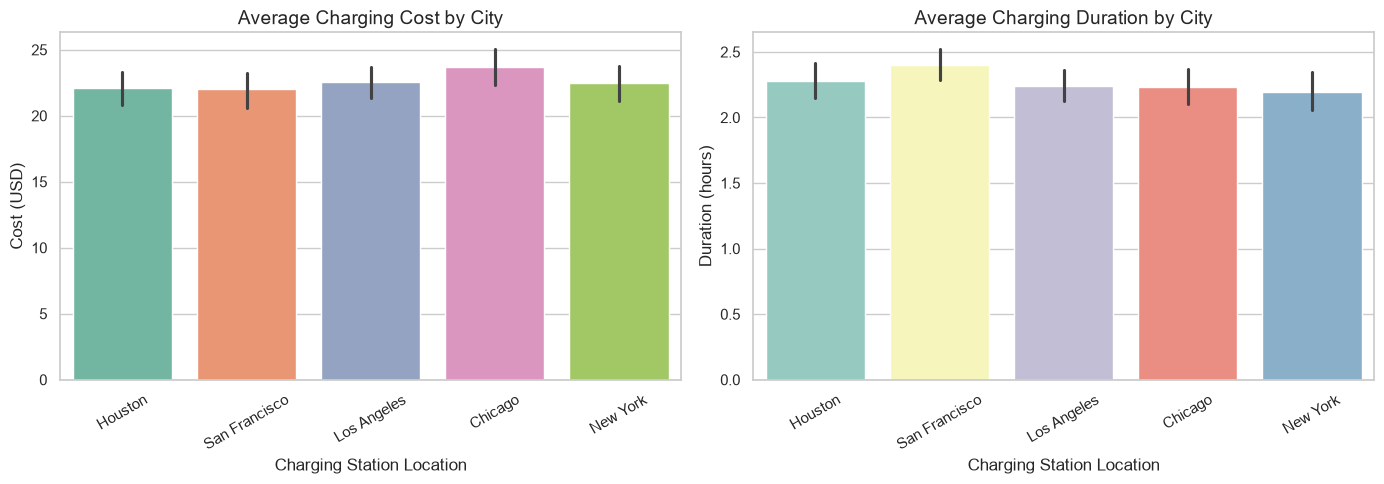

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Charging Station Location', y='Charging Cost (USD)', ax=axes[0], palette='Set2')
axes[0].set_title('Average Charging Cost by City')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Cost (USD)')

sns.barplot(data=df, x='Charging Station Location', y='Charging Duration (hours)', ax=axes[1], palette='Set3')
axes[1].set_title('Average Charging Duration by City')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Duration (hours)')

plt.tight_layout()
plt.show()

---
## 4. Hardware Impact: Charger Type

C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\777476424.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Charger Type', y='charging_efficiency', ax=axes[0], palette='rocket')
C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\777476424.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Charger Type', y='cost_per_kwh', ax=axes[1], palette='mako')


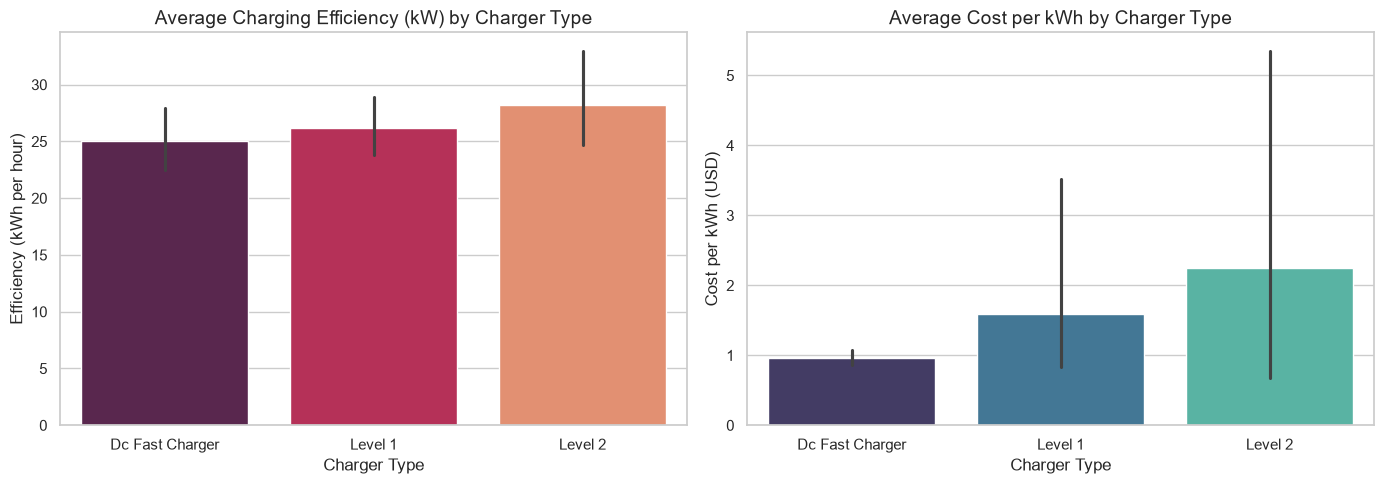

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Because of potential casing differences, map it directly or use the cleaned column
sns.barplot(data=df, x='Charger Type', y='charging_efficiency', ax=axes[0], palette='rocket')
axes[0].set_title('Average Charging Efficiency (kW) by Charger Type')
axes[0].set_ylabel('Efficiency (kWh per hour)')

sns.barplot(data=df, x='Charger Type', y='cost_per_kwh', ax=axes[1], palette='mako')
axes[1].set_title('Average Cost per kWh by Charger Type')
axes[1].set_ylabel('Cost per kWh (USD)')

plt.tight_layout()
plt.show()

---
## 5. Behavioral Segmentation: User Type

C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\490255576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='User Type', y='Distance Driven (since last charge) (km)', ax=axes[0], palette='viridis')
C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\490255576.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='User Type', y='soc_gained_pct', ax=axes[1], palette='viridis')


C:\Users\sskor\AppData\Local\Temp\ipykernel_26696\490255576.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='User Type', y='Charging Duration (hours)', ax=axes[2], palette='viridis')


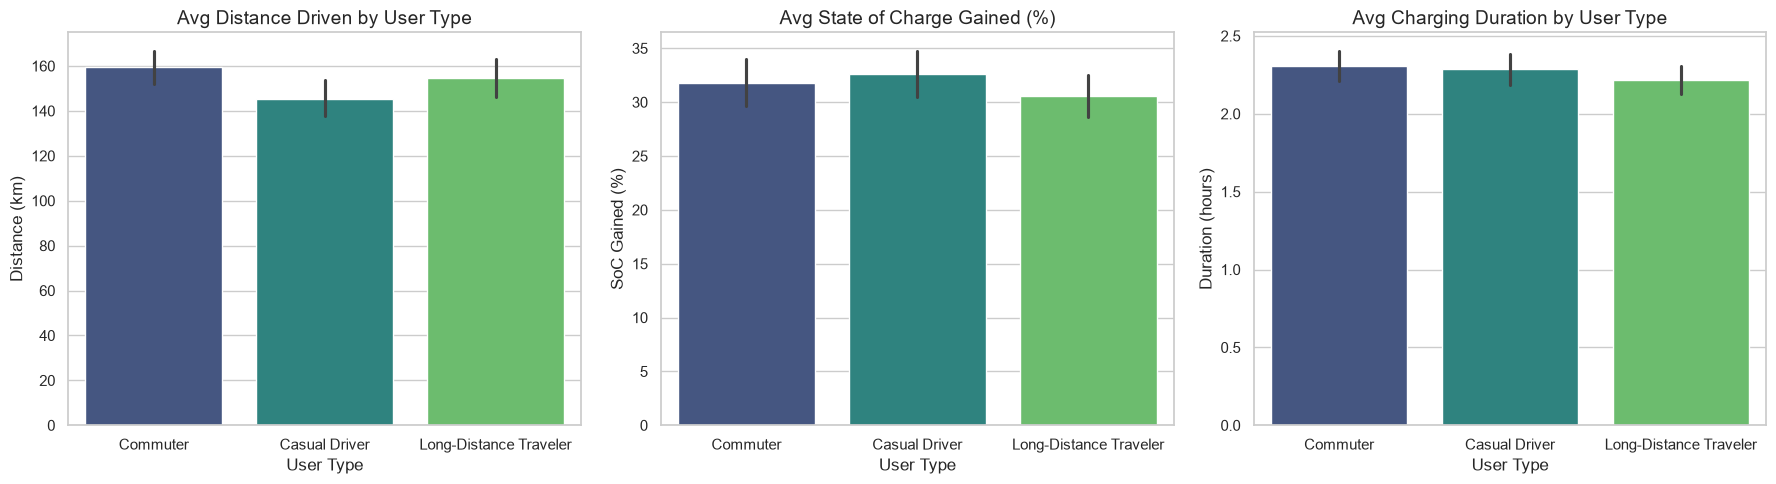

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='User Type', y='Distance Driven (since last charge) (km)', ax=axes[0], palette='viridis')
axes[0].set_title('Avg Distance Driven by User Type')
axes[0].set_ylabel('Distance (km)')

sns.barplot(data=df, x='User Type', y='soc_gained_pct', ax=axes[1], palette='viridis')
axes[1].set_title('Avg State of Charge Gained (%)')
axes[1].set_ylabel('SoC Gained (%)')

sns.barplot(data=df, x='User Type', y='Charging Duration (hours)', ax=axes[2], palette='viridis')
axes[2].set_title('Avg Charging Duration by User Type')
axes[2].set_ylabel('Duration (hours)')

plt.tight_layout()
plt.show()

---
## 6. Environmental Factors: Temperature vs Charging Rate

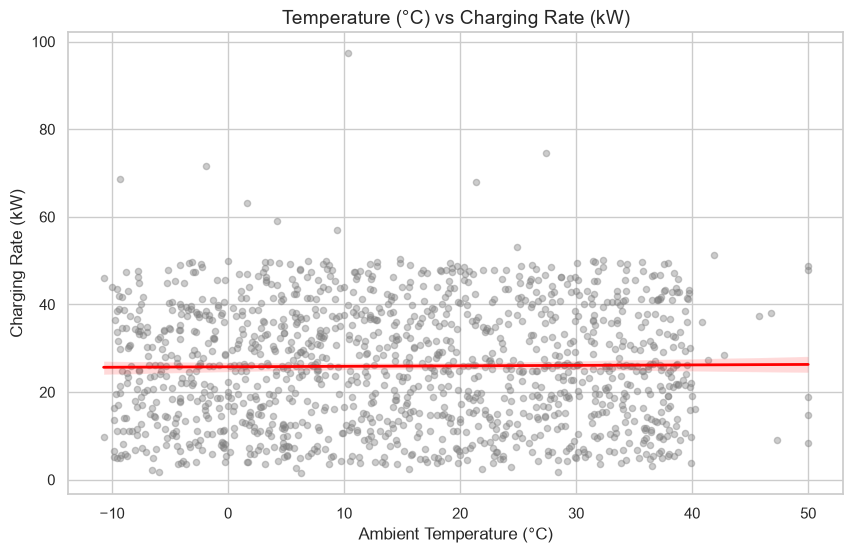

In [7]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Temperature (C)', y='Charging Rate (kW)', 
            scatter_kws={'alpha':0.4, 's':20, 'color':'gray'}, 
            line_kws={'color':'red', 'lw':2})

plt.title('Temperature (°C) vs Charging Rate (kW)')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Charging Rate (kW)')
plt.show()

---
## 7. Feature Correlation Heatmap

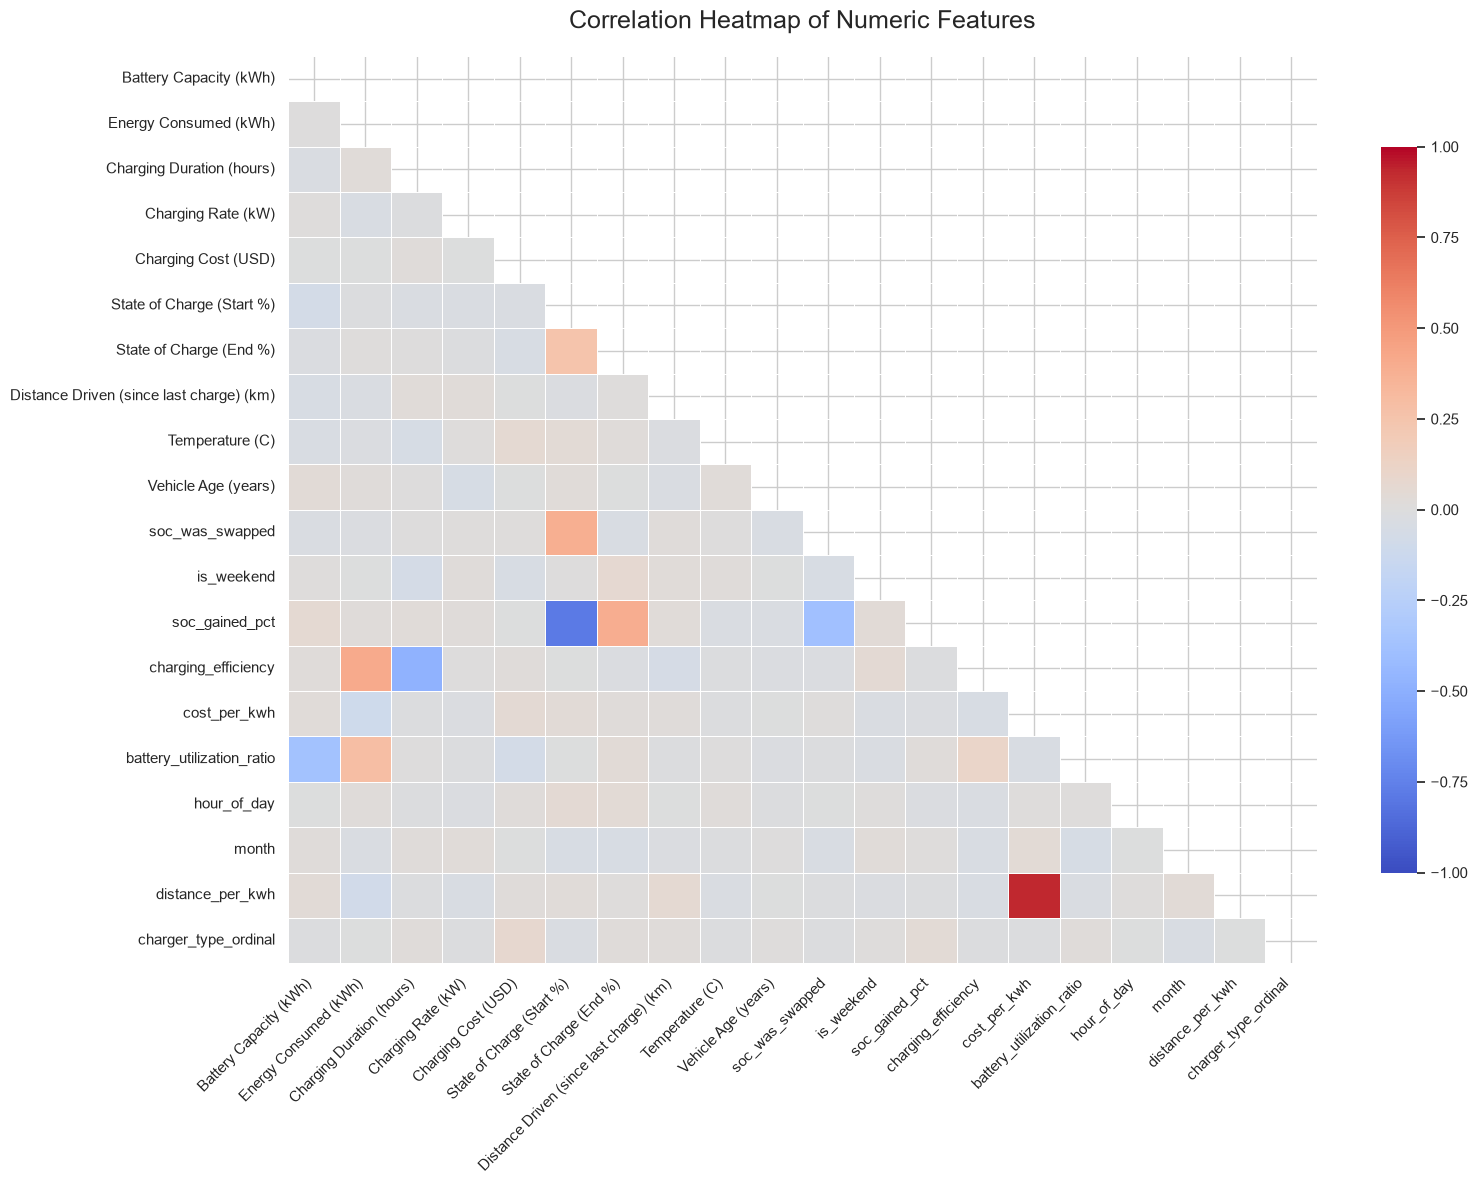

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Numeric Features', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 8. Key Insights & Business Findings 

Based on the exploratory analysis of 1,320 EV charging sessions, here are the most critical takeaways for network operators:

*   **Afternoon Surges:** The Afternoon time bucket experiences the highest energy demand (averaging **43.3 kWh** per session) and the highest charging costs (**$23.13**). Operators should consider dynamic peak-pricing strategies or load balancing during these hours.
*   **Chicago Premium:** Across the 5 cities analyzed, Chicago has the highest average charging cost (**$23.72**), notably out-pricing markets like San Francisco (**$21.99**). This indicates strong local pricing power or higher grid costs that need to be evaluated.
*   **User Segment Driving Habits:** Interestingly, **Commuters** drive the furthest between charges (avg **159.3 km**), outpacing even Long-Distance Travelers (avg **154.8 km**). This suggests Commuters arrive with highly depleted batteries and represent a captive audience for fast-charging services.
*   **Charger Type Anomalies:** In this dataset, DC Fast Chargers surprisingly exhibit a lower average cost per kWh (**$0.96/kWh**) compared to Level 1 (**$1.60**) and Level 2 (**$2.25**). This pricing inversion could represent a massive revenue leak or an aggressive, loss-leading customer acquisition strategy by the network operator.
*   **Flat Session Durations:** Despite massive differences in charging hardware (DC Fast vs Level 1), the average session duration remains flat across all charger types at roughly **~2.2 to 2.3 hours**. Users seem to budget a specific amount of *time* to charge, rather than staying until full, making time-based idle fees critical to improving station throughput.
